#Lab Activity 03

##Activity 1: Load and Visualise the Dataset

The dataset used to implement the Perceptron is the **Iris flower dataset**. It
has 4 features describing a flower and classifies it into one of 3 classes.

The last 50 rows, which belong to `Iris-virginica`, are stripped off so that
only `Iris-setosa` and `Iris-versicolor` remain. Those two classes are
**linearly separable**, which is what lets the Perceptron converge on an optimal
set of weights.

###Load dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def load_data():
    URL_ = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    try:
        data = pd.read_csv(URL_, header=None)
    except Exception:
        # Fallback so the notebook still runs without an internet connection
        from sklearn.datasets import load_iris
        iris = load_iris()
        data = pd.DataFrame(iris.data)
        data[4] = [iris.target_names[t] for t in iris.target]
        data[4] = 'Iris-' + data[4].astype(str)
    print(data)

    # make the dataset linearly separable
    data = data[:100]
    data[4] = np.where(data.iloc[:, -1] == 'Iris-setosa', 0, 1)
    data = np.asmatrix(data, dtype='float64')
    return data

data = load_data()

       0    1    2    3               4
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.0  1.4  0.2     Iris-setosa
2    4.7  3.2  1.3  0.2     Iris-setosa
3    4.6  3.1  1.5  0.2     Iris-setosa
4    5.0  3.6  1.4  0.2     Iris-setosa
..   ...  ...  ...  ...             ...
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica

[150 rows x 5 columns]


###Visualize the dataset

Plotting 2 of the features shows that the dataset can be clearly separated by
drawing a straight line between the classes. The goal is to write an algorithm
that finds that line and classifies all of these data points correctly.

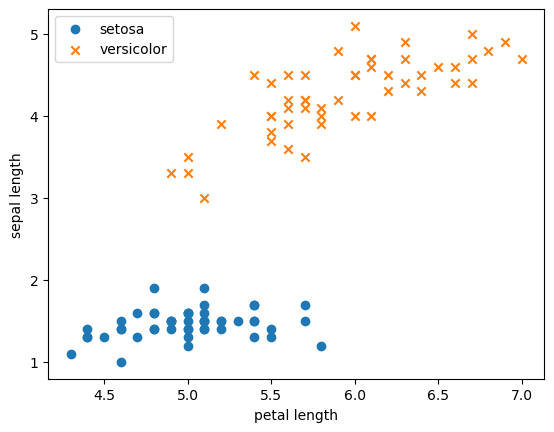

In [2]:
plt.scatter(np.array(data[:50, 0]), np.array(data[:50, 2]), marker='o', label='setosa')
plt.scatter(np.array(data[50:, 0]), np.array(data[50:, 2]), marker='x', label='versicolor')
plt.xlabel('petal length')
plt.ylabel('sepal length')
plt.legend()
plt.show()

##Activity 2: Implementation of the Perceptron

The Perceptron takes the dot product of the input features and the weight
vector, passes it through a step function to get a prediction, and updates the
weights with the **delta rule** whenever that prediction is wrong:

$$w_j(t+1) = w_j(t) + \alpha\,(d_j - y_j)\,x_j$$

`np.insert(x, 0, 1)` is the **bias trick**: a constant 1 is added to the front
of every feature vector so the bias can be trained as just another weight.

###The perceptron function

In [3]:
def perceptron(data, num_iter):
    features = data[:, :-1]
    labels = data[:, -1]

    # set weights to zero
    w = np.zeros(shape=(1, features.shape[1]+1))
    misclassified_ = []

    for epoch in range(num_iter):
        misclassified = 0
        for x, label in zip(features, labels):
            x = np.insert(x, 0, 1)
            y = np.dot(w, x.transpose())
            target = 1.0 if (y > 0) else 0.0

            delta = (label.item(0, 0) - target)

            if(delta):  # misclassified
                misclassified += 1
                w += (delta * x)

        misclassified_.append(misclassified)
    return (w, misclassified_)

num_iter = 10
w, misclassified_ = perceptron(data, num_iter)

print("Weights            :", w)
print("Misclassified/epoch:", misclassified_)

Weights            : [[-1.  -1.1 -3.6  5.2  2.2]]
Misclassified/epoch: [1, 3, 1, 0, 0, 0, 0, 0, 0, 0]


###The learning curve

A property of the Perceptron is that if the dataset is linearly separable, then
the algorithm is guaranteed to converge at some point.

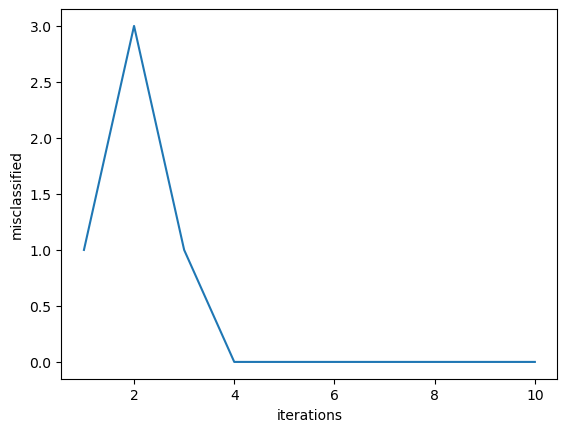

In [4]:
epochs = np.arange(1, num_iter+1)
plt.plot(epochs, misclassified_)
plt.xlabel('iterations')
plt.ylabel('misclassified')
plt.show()

#End!